In [1]:
import os
import polars as pl
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from src.etl import ETL

In [29]:
BASE_PATH: str = os.path.join('.', 'src', 'files')
RANDOM_SEED: float = 0

sns.set_theme(style="darkgrid")

In [3]:
df_raw: pl.DataFrame = pl.read_csv(
    os.path.join(BASE_PATH, 'mock_data', 'mock_sales_data.csv'),
    schema_overrides={
        'SaleDate': pl.Date,
        'ProductID': pl.String,
        'ASP': pl.Float32,
        'QT': pl.Int32,
    }
)

In [4]:
df_raw.head(5)

SaleDate,ProductID,ASP,QT
date,str,f32,i32
2020-01-01,"""P001""",97.769997,13
2020-01-01,"""P001""",97.260002,16
2020-01-01,"""P001""",97.110001,12
2020-01-01,"""P001""",96.580002,21
2020-01-01,"""P001""",97.230003,12


In [5]:
df_raw.select(pl.col('ProductID')).unique().count().item()

10

In [6]:
df_raw = df_raw.with_columns(
    pl.col('SaleDate').dt.year().alias('Y'),
    pl.col('SaleDate').dt.month().alias('M'),
    pl.concat_str(
        pl.col('SaleDate').dt.to_string('%Y'),
        pl.col('SaleDate').dt.to_string('%m'),
        separator='/'
    ).alias('YearMonth')
)

In [7]:
for product in df_raw.sort(by='ProductID').select(pl.col('ProductID')).unique().to_numpy():
    min_date: dt.date = df_raw.filter(pl.col('ProductID') == product).select(pl.col('YearMonth')).min().item()
    max_date: dt.date = df_raw.filter(pl.col('ProductID') == product).select(pl.col('YearMonth')).max().item()

    print(f'Product: {product} - Min Date: {min_date} - Max Date: {max_date}')

Product: ['P001'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P002'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P003'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P004'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P005'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P006'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P007'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P008'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P009'] - Min Date: 2020/01 - Max Date: 2026/06
Product: ['P010'] - Min Date: 2020/01 - Max Date: 2026/06


In [8]:
etl: ETL = ETL()

In [12]:
df_QT: pd.DataFrame = etl.prepare_dataframe(
    df=df_raw.to_pandas(),
    x='ProductID',
    y='QT',
    date_cut='2026/01'
)

df_QT: pl.DataFrame = pl.from_pandas(df_QT)

In [15]:
df_QT.head(5)

ProductID,ds,y
str,datetime[μs],i32
"""P001""",2020-01-01 00:00:00,2952
"""P003""",2020-01-01 00:00:00,1722
"""P005""",2020-01-01 00:00:00,1982
"""P006""",2020-01-01 00:00:00,655
"""P002""",2020-01-01 00:00:00,3502


In [80]:
#df_QT.group_by(
#    'ProductID'
#).agg(
#    pl.col('Produ').count()
#)

SyntaxError: Invalid star expression (2361160477.py, line 4)

In [21]:
df_QT = df_QT.sort(by='ds')

In [27]:
def line_plot(df: pl.DataFrame, x: str, y: str, hue: str) -> None:
    fig, ax = plt.subplots(figsize=(18, 6))
    sns.lineplot(data=df, x=x, y=y, hue=hue, ax=ax)

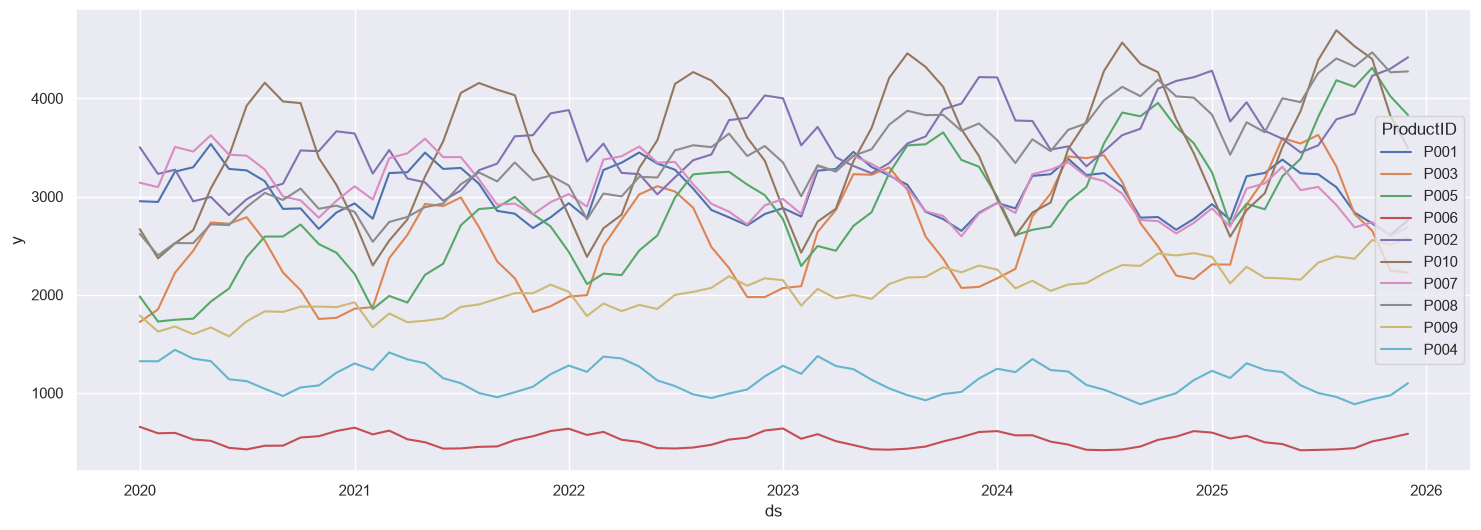

In [28]:
line_plot(df_QT, x='ds', y='y', hue='ProductID')

In [79]:
noise_percentage: float = 0.05

df_QT: pl.DataFrame = df_QT.with_columns(
    (
        pl.col('y') *
        pl.lit(
            np.random.normal(loc=1.0, scale=noise_percentage, size=len(df_QT))
        )
    ).over('ProductID').alias('y')
)

ShapeError: expressions must have matching group lengths

This error occurred in the following expression:
	[(col("y").cast(Float64)) * (Series[literal])]
while evaluating this larger expression:
	[(col("y").cast(Float64)) * (Series[literal])].over([col("ProductID")])
